The objective of this analysis is to develop a machine learning model aimed at predicting injury risk in athletes. Once the model is constructed, a thorough analysis will be conducted to identify the most influential variables in determining injury risk. Additionally, the analysis will explore the optimal thresholds at which these variables should be adjusted to mitigate the likelihood of injury.

The model was developed using a dataset sourced from Kaggle, which contains information on collegiate athlete injury rates and performance metrics.

In [1]:
%pip install imbalanced-learn

In [2]:
%pip install seaborn

In [3]:
%pip install statsmodels

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,recall_score,precision_score,f1_score, accuracy_score,classification_report

<ipython-input-4-abbe307e0910>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [5]:
df = pd.read_csv('collegiate_athlete_injury_dataset.csv')

In [6]:
df.head(5)

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Athlete_ID                200 non-null    object
 1   Age                       200 non-null    int64 
 2   Gender                    200 non-null    object
 3   Height_cm                 200 non-null    int64 
 4   Weight_kg                 200 non-null    int64 
 5   Position                  200 non-null    object
 6   Training_Intensity        200 non-null    int64 
 7   Training_Hours_Per_Week   200 non-null    int64 
 8   Recovery_Days_Per_Week    200 non-null    int64 
 9   Match_Count_Per_Week      200 non-null    int64 
 10  Rest_Between_Events_Days  200 non-null    int64 
 11  Fatigue_Score             200 non-null    int64 
 12  Performance_Score         200 non-null    int64 
 13  Team_Contribution_Score   200 non-null    int64 
 14  Load_Balance_Score        

In [8]:
#Check class balance
df['Injury_Indicator'].value_counts(normalize=True)*100

Injury_Indicator
0    93.0
1     7.0
Name: proportion, dtype: float64

The dataset exhibits a notable class imbalance, which will be addressed and corrected during model building. The initial model to be constructed and evaluated is a Random Forest model.

In [9]:
#Drop Athlete_ID and ACL_Risk_Score columns
df_subset = df.drop(['Athlete_ID','ACL_Risk_Score'],axis=1)

In [10]:
# Dummy encode Gender and Position variables
df_subset = pd.get_dummies(df_subset,drop_first = 'True')

In [11]:
#Split data into feature and target variables and into training data and test data
y = df_subset['Injury_Indicator']
X = df_subset.copy()
X = X.drop('Injury_Indicator',axis = 1)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,stratify=y,random_state=42)

In [12]:
#Apply SMOTE to oversample the minority class and correct for class imbalance
smote = SMOTE(sampling_strategy = 'auto',random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [13]:
#Hyperparameter tuning
rf=RandomForestClassifier(class_weight = 'balanced',random_state=0)
cv_params = {'max_depth':[2,3,4,5],
             'min_samples_leaf':[1,2,3],
             'min_samples_split':[2,3],
             'max_features':[2,3,4],
             'n_estimators':[75,100,125,150]}
rf_cv = GridSearchCV(rf,cv_params,scoring=['accuracy','recall','precision','f1'],cv=5,refit='recall')

In [15]:
#Fit the model to the training data
#rf_cv.fit(X_resampled,y_resampled)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=0),
             param_grid={'max_depth': [2, 3, 4, 5], 'max_features': [2, 3, 4],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 125, 150]},
             refit='recall', scoring=['accuracy', 'recall', 'precision', 'f1'])

In [14]:
import pickle

#with open('rf_cv_model.pickle','wb') as to_write:
    #pickle.dump(rf_cv,to_write)

In [15]:
with open('rf_cv_model.pickle','rb') as to_read:
    rf_cv = pickle.load(to_read)

In [16]:
#Check results from the Random Forest Model
def make_results(model_name,model_object):
    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_recall'].idxmax(),:]
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    accuracy = best_estimator_results.mean_test_accuracy
    precision = best_estimator_results.mean_test_precision
    table = pd.DataFrame({'Model':[model_name],
                            'f1':[f1],
                            'Recall':[recall],
                            'Accuracy':[accuracy],
                             'Precision':[precision]})
    return table
rf_cv_results = make_results('Random Forest CV', rf_cv)
rf_cv_results

,Model,f1,Recall,Accuracy,Precision
0,Random Forest CV,0.961628,0.985714,0.960455,0.939726


In [17]:
#Validate the model using the test data
rf_val_preds = rf_cv.best_estimator_.predict(X_test)

In [18]:
#Get scores for the test data
def get_test_scores(model_name,preds,y_test_data):
    f1 = f1_score(y_test_data,preds)
    recall = recall_score(y_test_data,preds)
    accuracy = accuracy_score(y_test_data,preds)
    precision = precision_score(y_test_data,preds)
    table = pd.DataFrame({'Model':[model_name],
                            'f1':[f1],
                            'Recall':[recall],
                            'Accuracy':[accuracy],
                             'Precision':[precision]})
    return table
rf_val_scores = get_test_scores('Random Forest Validation',rf_val_preds,y_test)
rf_val_scores                           

/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,f1,Recall,Accuracy,Precision
0,Random Forest Validation,0.0,0.0,0.94,0.0


In [19]:
results = pd.concat([rf_cv_results,rf_val_scores],axis=0)
results

,Model,f1,Recall,Accuracy,Precision
0,Random Forest CV,0.961628,0.985714,0.960455,0.939726
0,Random Forest Validation,0.000000,0.000000,0.940000,0.000000


The suboptimal performance observed during validation suggests that the model may be overfitting to the training data.

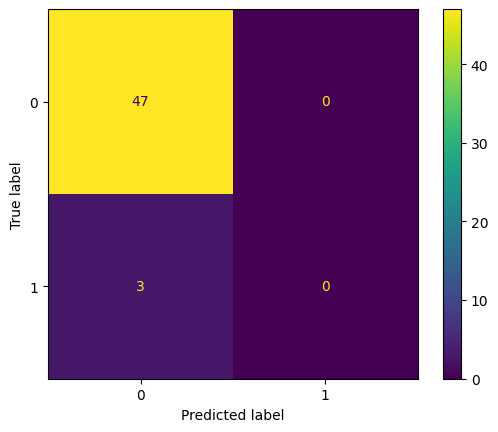

In [20]:
#Check the confusion matrix for the Random Forest model
def conf_matrix_plot(model,X_data,y_data):
    model_pred = model.predict(X_data)
    cm = confusion_matrix(y_data,model_pred,labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels=model.classes_)
    disp.plot() 
    plt.show()
conf_matrix_plot(rf_cv,X_test,y_test)

The Random Forest model is not predicting any positive outcomes, which may be attributed to factors such as class imbalance, a small sample size, or potential overfitting to the training data. As the next step, I will implement an XGBoost model and evaluate its performance in comparison to the Random Forest model.

In [21]:
from xgboost import XGBClassifier
from xgboost import plot_importance

In [23]:
#Split data into feature and target variables and into training data and test data
y = df_subset['Injury_Indicator']
X = df_subset.copy()
X = X.drop('Injury_Indicator',axis = 1)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,stratify=y,random_state=42)

In [36]:
xgb = XGBClassifier(objective='binary:logistic',random_state=0)
cv_params_xgb = {'max_depth':[4,5,6],
                 'min_child_weight':[1,3,5],
                 'learning_rate':[0.1,0.2,0.3],
                 'n_estimators':[75,100,125]}
xgb_cv = GridSearchCV(xgb,cv_params_xgb,scoring=['accuracy','precision','recall','f1'],cv=5,refit='recall')

In [37]:
#Fit the model
#xgb_cv.fit(X_resampled,y_resampled)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.1, 0.2, 0.3],
                         'max_depth': [4, 5, 6], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [75, 100, 125]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [39]:
#with open('xgb_cv.pickle','wb') as to_write:
    #pickle.dump(xgb_cv,to_write)

In [24]:
with open('xgb_cv.pickle','rb') as to_read:
    xgb_cv = pickle.load(to_read)

In [25]:
#Check XGBoost model results
def make_results(model_name,model_object):
    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_recall'].idxmax(),:]
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    accuracy = best_estimator_results.mean_test_accuracy
    precision = best_estimator_results.mean_test_precision
    table = pd.DataFrame({'Model':[model_name],
                            'f1':[f1],
                            'Recall':[recall],
                            'Accuracy':[accuracy],
                             'Precision':[precision]})
    return table
xgb_cv_results = make_results('XGBoost', xgb_cv)
xgb_cv_results

,Model,f1,Recall,Accuracy,Precision
0,XGBoost,0.968653,0.985714,0.967792,0.952813


In [26]:
results = pd.concat([results,xgb_cv_results],axis=0)
results

,Model,f1,Recall,Accuracy,Precision
0,Random Forest CV,0.961628,0.985714,0.960455,0.939726
0,Random Forest Validation,0.000000,0.000000,0.940000,0.000000
0,XGBoost,0.968653,0.985714,0.967792,0.952813


In [27]:
#Use test data to test the performance of the XGBoost model
xgb_cv_preds = xgb_cv.predict(X_test)

In [28]:
#Check the XGBoost model performance on the test data
def get_test_scores(model_name,preds,y_test_data):
    f1 = f1_score(y_test_data,preds)
    recall = recall_score(y_test_data,preds)
    accuracy = accuracy_score(y_test_data,preds)
    precision = precision_score(y_test_data,preds)
    table = pd.DataFrame({'Model':[model_name],
                            'f1':[f1],
                            'Recall':[recall],
                            'Accuracy':[accuracy],
                             'Precision':[precision]})
    return table
xgb_cv_scores = get_test_scores('XGBoost Validation',xgb_cv_preds,y_test)
xgb_cv_scores

,Model,f1,Recall,Accuracy,Precision
0,XGBoost Validation,0.5,0.333333,0.96,1.0


In [29]:
results = pd.concat([results,xgb_cv_scores],axis=0)
results

,Model,f1,Recall,Accuracy,Precision
0,Random Forest CV,0.961628,0.985714,0.960455,0.939726
0,Random Forest Validation,0.000000,0.000000,0.940000,0.000000
0,XGBoost,0.968653,0.985714,0.967792,0.952813
0,XGBoost Validation,0.500000,0.333333,0.960000,1.000000


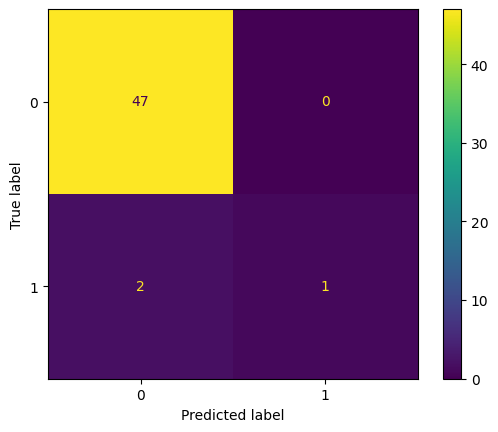

In [30]:
#Check the confusion matrix
def conf_matrix_plot(model,X_data,y_data):
    model_pred = model.predict(X_data)
    cm = confusion_matrix(y_data,model_pred,labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels=model.classes_)
    disp.plot() 
    plt.show()
conf_matrix_plot(xgb_cv,X_test,y_test)

The XGBoost model demonstrated marginally superior performance compared to the Random Forest model in predicting athlete injury risk. The next step will involve analyzing the most important features utilized by the models in making their predictions.

Permutation importance was used to assess feature importance, providing a more accurate evaluation of feature contributions, particularly in the presence of feature correlation.

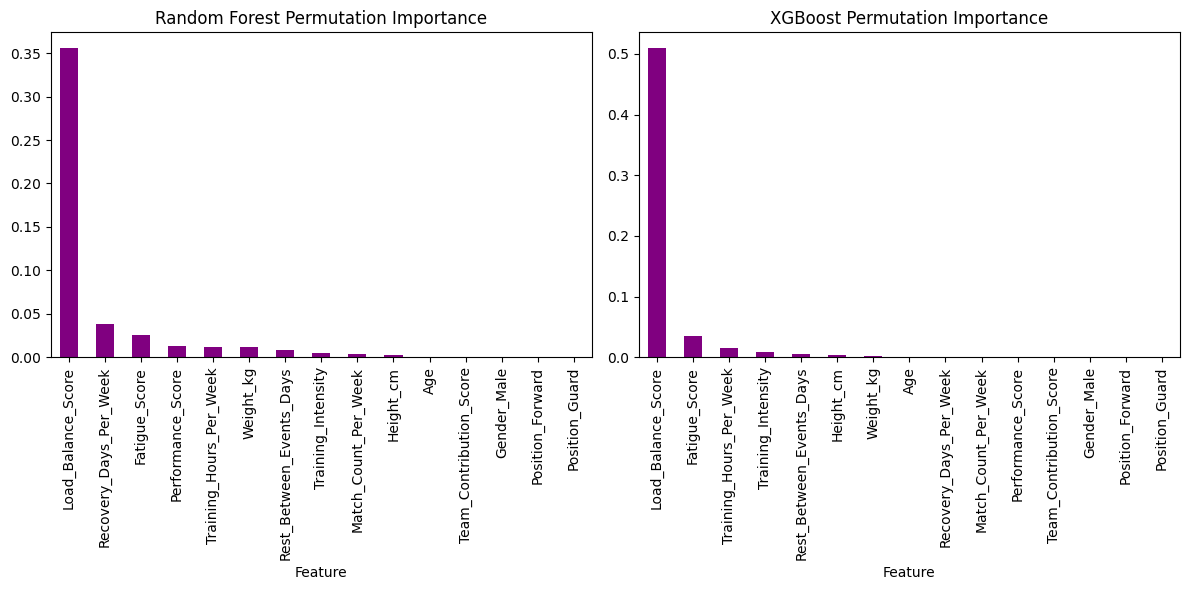

In [32]:
#Compare permutation importance for the Random Forest model and the XGBoost model
from sklearn.inspection import permutation_importance

results_permutation_rf = permutation_importance(rf_cv, X_resampled, y_resampled, n_repeats=10, random_state=42)
perm_importance_df_rf = pd.DataFrame({
    'Feature': X_resampled.columns,
    'Permutation Importance': results_permutation_rf.importances_mean
}).sort_values(by='Permutation Importance', ascending=False)

results_permutation_xgb = permutation_importance(xgb_cv, X_resampled, y_resampled, n_repeats=10, random_state=42)
perm_importance_df_xgb = pd.DataFrame({
    'Feature': X_resampled.columns,
    'Permutation Importance': results_permutation_xgb.importances_mean
}).sort_values(by='Permutation Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

perm_importance_df_rf.plot.bar(x='Feature', y='Permutation Importance', ax=axes[0],
                               color='purple', legend=False, title='Random Forest Permutation Importance')

perm_importance_df_xgb.plot.bar(x='Feature', y='Permutation Importance', ax=axes[1],
                                color='purple', legend=False, title='XGBoost Permutation Importance')

plt.tight_layout()
plt.show()

The features Load_Balance_Score, Recovery_Days_Per_Week, Fatigue_Score, Training_Hours_Per_Week, Training_Intensity, and Performance_Score were identified as the most significant predictors of athlete injury risk and were subsequently analyzed in greater detail.

In [83]:
#Chi-Square test evaluate the relationship between each variable and the target variable
def chi_square_for_multiple_vars(df, variables, target):
    results = []
    for var in variables:
        contingency_table = pd.crosstab(df[var], df[target])
        chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
        results.append({
            'Variable': var,
            'Chi-Square Statistic': chi2_stat,
            'p-value': p_val,
            'Degrees of Freedom': dof
        })
    results_df = pd.DataFrame(results)
    
    return results_df

variables = ['Recovery_Days_Per_Week', 'Load_Balance_Score', 'Fatigue_Score', 'Training_Hours_Per_Week', 'Training_Intensity', 'Performance_Score']
target = 'Injury_Indicator'

chi_square_results = chi_square_for_multiple_vars(df_subset, variables, target)

print(chi_square_results)

                  Variable  Chi-Square Statistic       p-value  \
0   Recovery_Days_Per_Week             18.423525  9.985788e-05   
1       Load_Balance_Score            115.089817  6.703510e-12   
2            Fatigue_Score             23.456145  2.825411e-03   
3  Training_Hours_Per_Week             11.289191  6.631832e-01   
4       Training_Intensity              5.523574  7.004268e-01   
5        Performance_Score             37.338161  8.668586e-01   

   Degrees of Freedom  
0                   2  
1                  30  
2                   8  
3                  14  
4                   8  
5                  48  


The variables Training_Hours_Per_Week, Training_Intensity, and Performance_Score all have p-values greater than 0.05, suggesting that there is no statistically significant relationship between these variables and the target variable, Injury_Indicator. Therefore, further investigation will focus on the variables Load_Balance_Score, Recovery_Days_Per_Week, and Fatigue_Score.

In [85]:
#Calculate decision boundaries for Load_Balance_Score, Recovery_Days_Per_Week, and Fatigue_Score
def calculate_decision_boundaries(df, features, target):
    decision_boundaries = {}
    for feature in features:
        X = df[[feature]]
        y = df[target]

        model = LogisticRegression()
        model.fit(X, y)

        X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        y_prob = model.predict_proba(X_test)[:, 1]

        decision_boundary_x = X_test[np.abs(y_prob - 0.5).argmin()]

        decision_boundaries[feature] = decision_boundary_x[0]

    return decision_boundaries

features = ['Load_Balance_Score', 'Recovery_Days_Per_Week', 'Fatigue_Score']
target = 'Injury_Indicator'

decision_boundaries = calculate_decision_boundaries(df_subset, features, target)

for feature, boundary in decision_boundaries.items():
    print(f"Decision boundary for {feature}: {boundary:.2f}")

/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Decision boundary for Load_Balance_Score: 72.36
Decision boundary for Recovery_Days_Per_Week: 1.00
Decision boundary for Fatigue_Score: 9.00


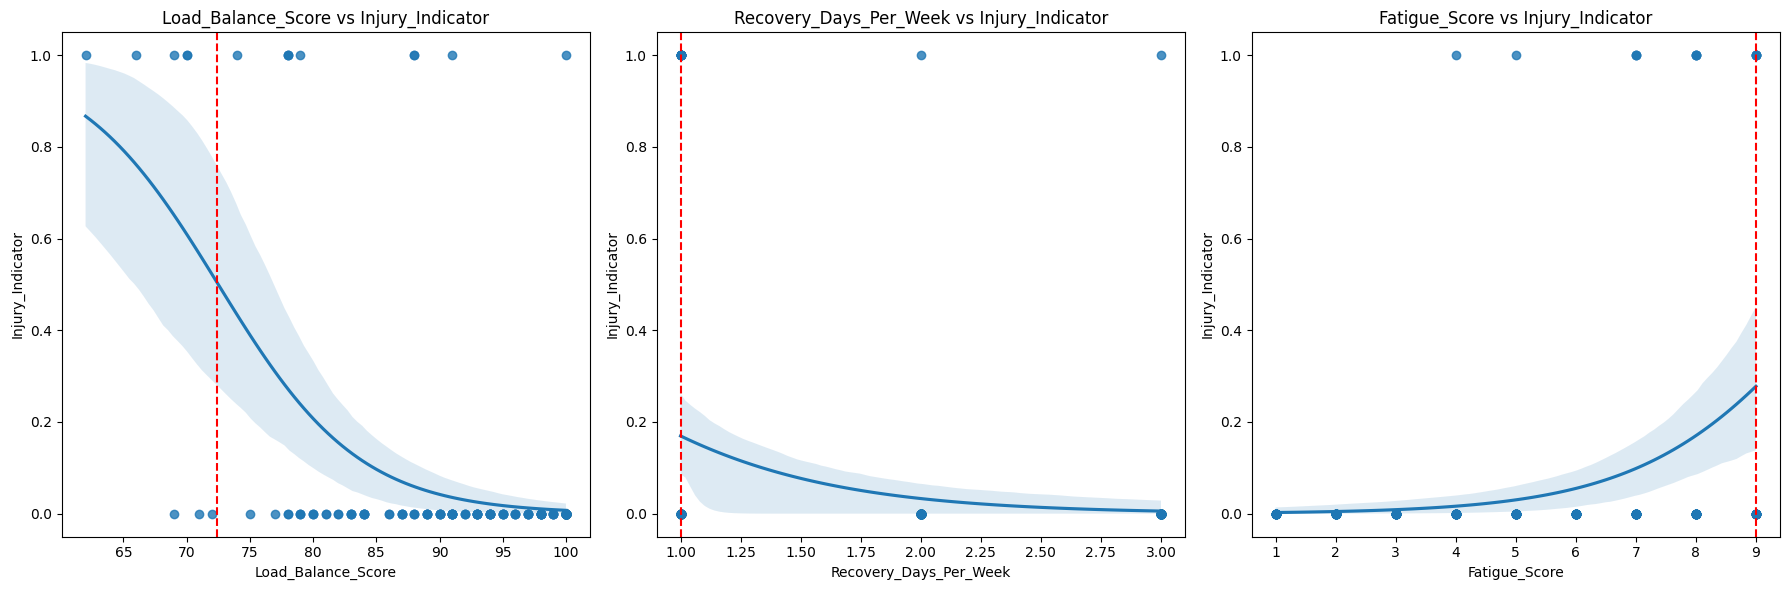

In [86]:
#Create regression plots for Load_Balance_Score, Recovery_Days_Per_Week, and Fatigue_Score to 
#better understand their relationship with Injury_Indicator
fig, axes = plt.subplots(1,3, figsize=(18, 6))

sns.regplot(x='Load_Balance_Score', y='Injury_Indicator', data=df_subset, logistic=True, ax=axes[0])
axes[0].set_title('Load_Balance_Score vs Injury_Indicator')
axes[0].axvline(x=decision_boundaries['Load_Balance_Score'], color='red', linestyle='--', label=decision_boundaries['Load_Balance_Score'])

sns.regplot(x='Recovery_Days_Per_Week', y='Injury_Indicator', data=df_subset, logistic=True, ax=axes[1])
axes[1].set_title('Recovery_Days_Per_Week vs Injury_Indicator')
axes[1].axvline(x=decision_boundaries['Recovery_Days_Per_Week'], color='red', linestyle='--', label=decision_boundaries['Recovery_Days_Per_Week'])


sns.regplot(x='Fatigue_Score', y='Injury_Indicator', data=df_subset, logistic=True, ax=axes[2])
axes[2].set_title('Fatigue_Score vs Injury_Indicator')
axes[2].axvline(x=decision_boundaries['Fatigue_Score'], color='red', linestyle='--', label=decision_boundaries['Fatigue_Score'])

plt.tight_layout()
plt.show()

This analysis suggests that to reduce the risk of injury in athletes, a Load_Balance_Score at or above 72.36, at least one Recovery_Day_Per_Week, and a Fatigue_Score of 9 or lower may contribute to minimizing injury risk.

However, further investigation using a larger dataset is recommended to improve the accuracy and robustness of the predictive model.